# knn is a very simple ml algo which work on the basic idea of selecting k neighers neighbours

Algo

<img src="../images/knn.png">

# how do we select k

two approaches

1 - heuristic 

    take an odd no close to the underoot of total no of features 

    dont work very well

2- experimental

    try different values of k and select the best one

# in knn there is no training part

In [1]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd

In [2]:
X, y = make_classification(n_samples=500,n_informative=2,n_features=2,n_redundant=0)

In [3]:
px.scatter(x=X[:,0],y=X[:,1],color=y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
knn=KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.96

# checking best value of k

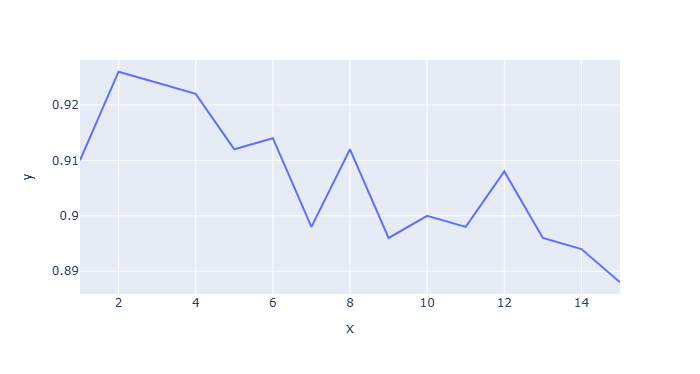

In [6]:
from sklearn.model_selection import GridSearchCV

gd=GridSearchCV(estimator=KNeighborsClassifier(),scoring='accuracy',param_grid={'n_neighbors':[i for i in range(1,16)]})

gd.fit(X,y)
results = gd.cv_results_['mean_test_score']
px.line(y=results,x=[i for i in range(1,16)])

# k- low => overfitting
# k- high => underfitting

# plotting descision boundary

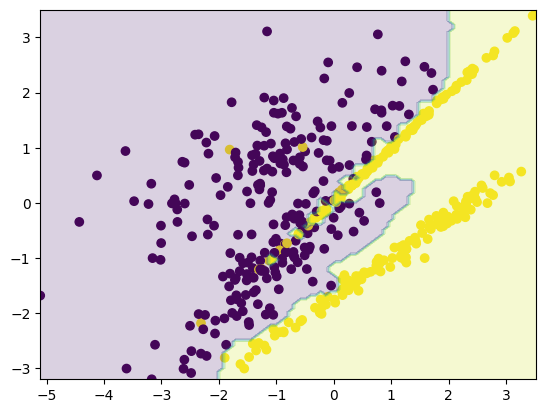

In [27]:
XX,yy=np.meshgrid(np.linspace(X[:,0].min(),X[:,0].max(),100),np.linspace(X[:,1].min(),X[:,1].max(),100))
plt.scatter(X[:,0],X[:,1],c=y)
grid_points = np.c_[XX.ravel(), yy.ravel()]  # shape (10000, 2)
Z = knn.predict(grid_points)
Z = Z.reshape(XX.shape)
plt.contourf(XX, yy, Z, alpha=0.2)

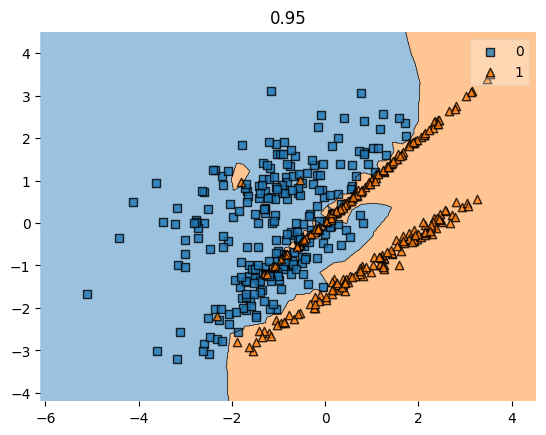

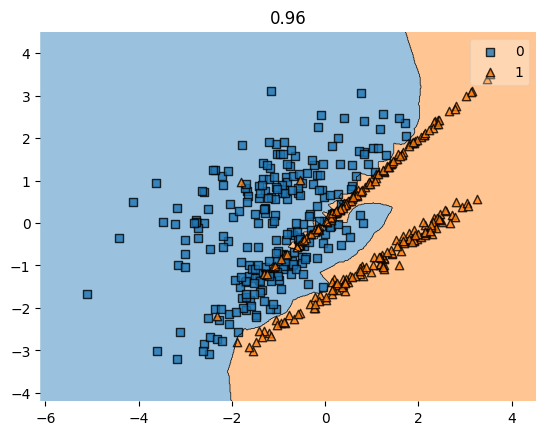

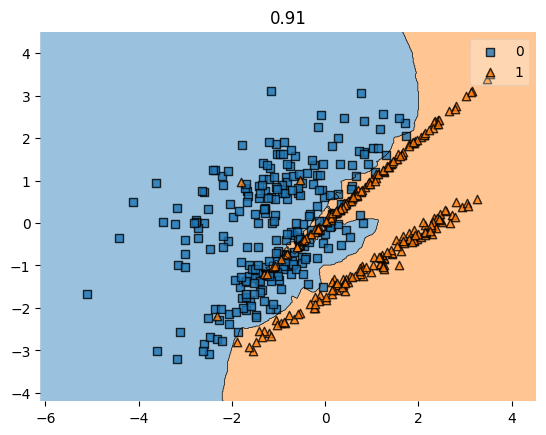

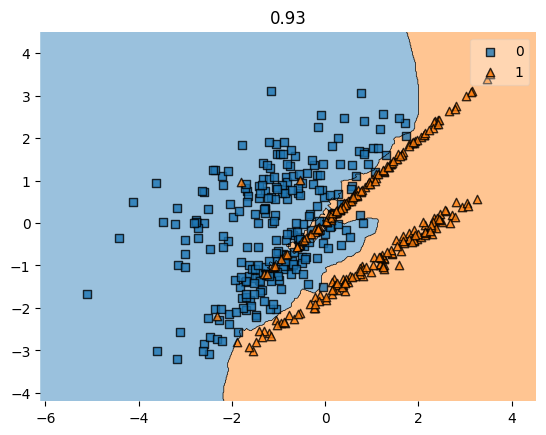

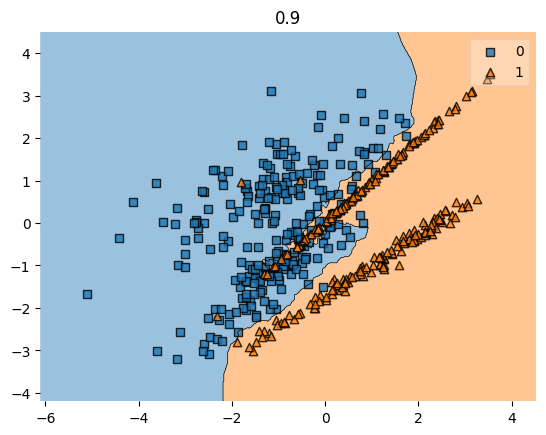

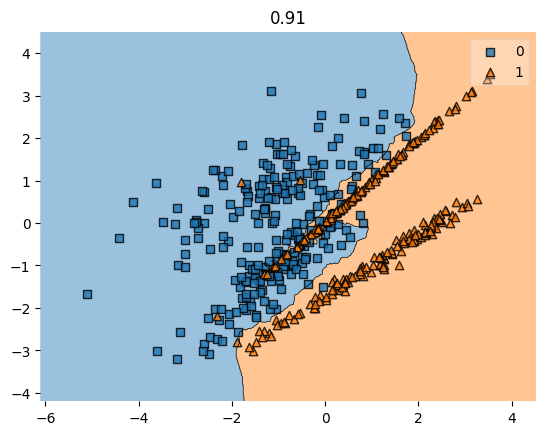

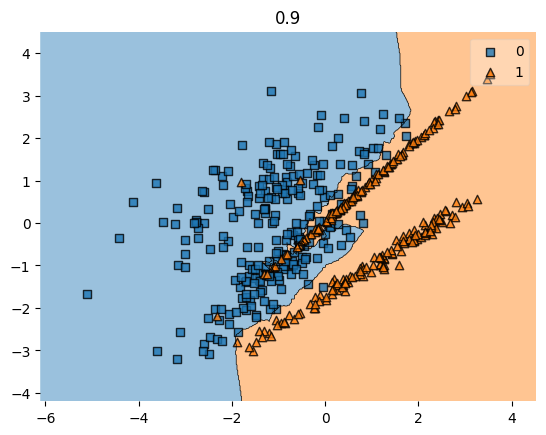

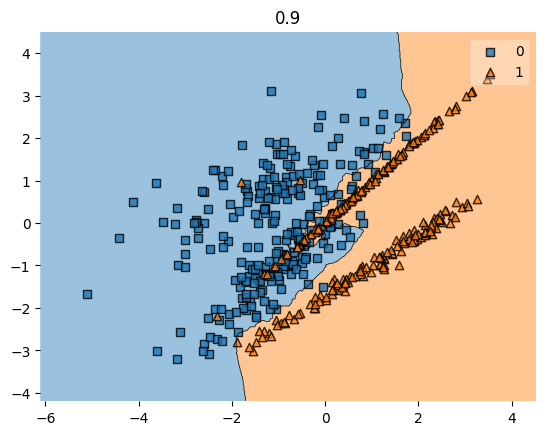

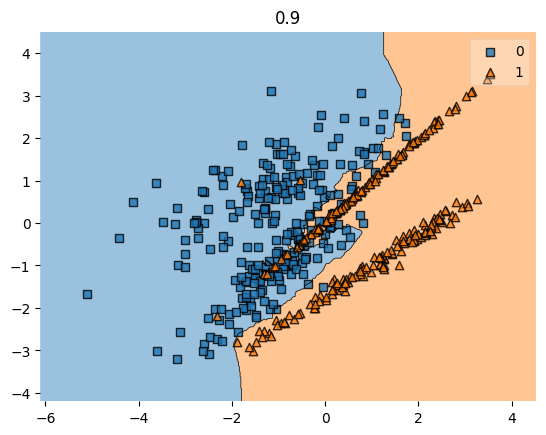

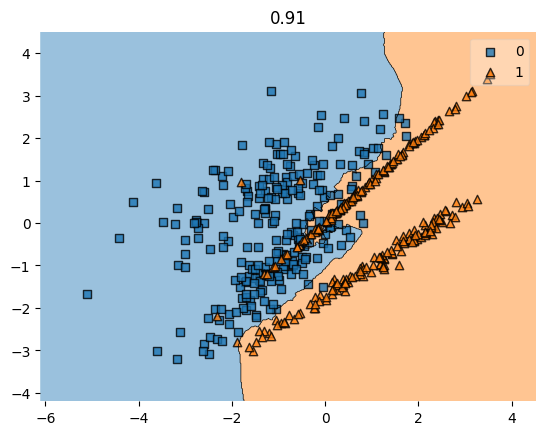

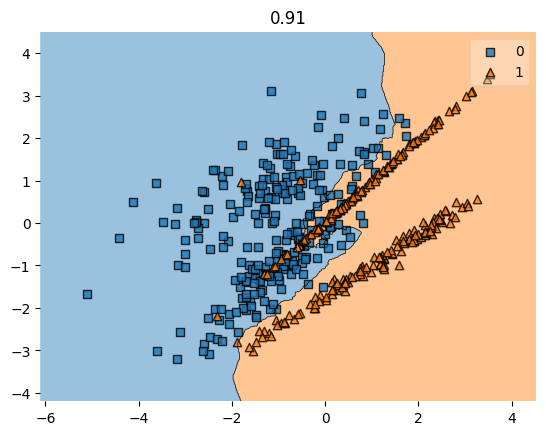

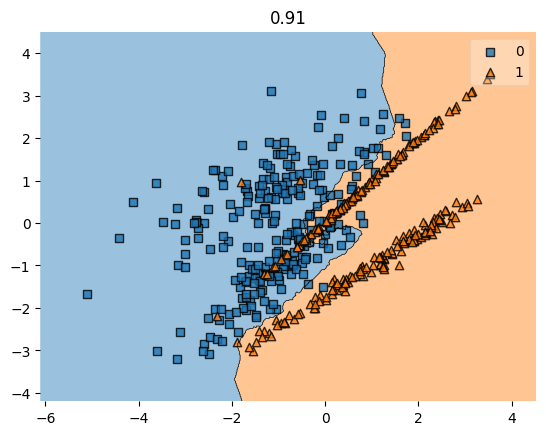

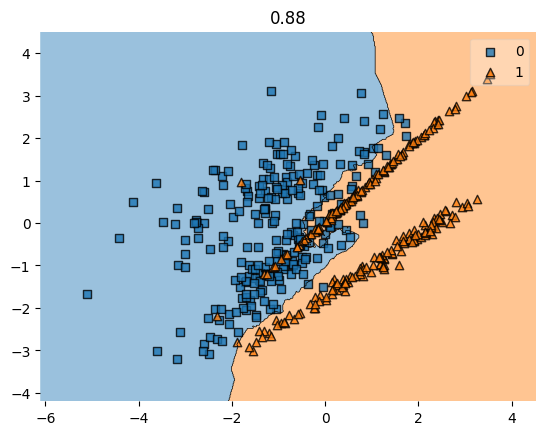

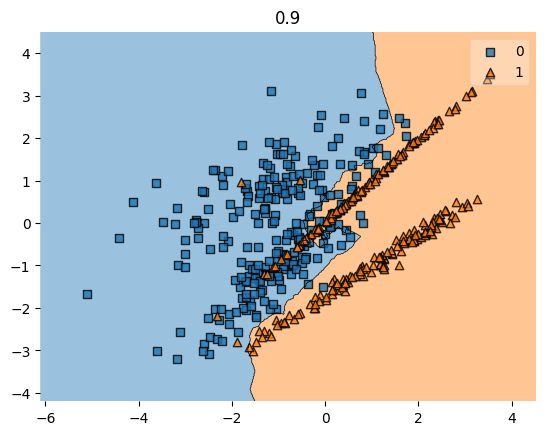

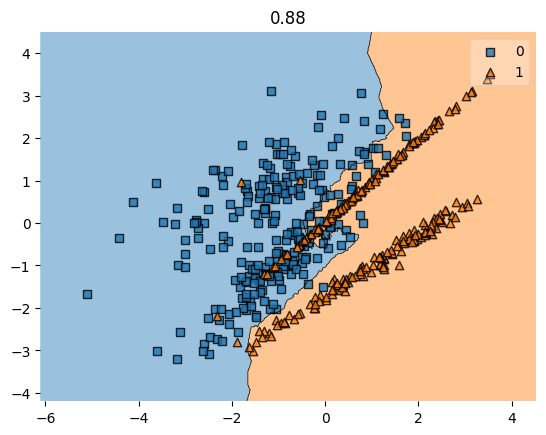

In [30]:
from mlxtend.plotting import plot_decision_regions

for i in range(1,16):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    plot_decision_regions(X,y,clf=knn)
    y_pred=knn.predict(X_test)
    plt.title(accuracy_score(y_test,y_pred))
    plt.show()

# Limitations of knn

<img src="../images/knn (2).png"/>